In [1]:
from DFTStructureGenerator.descriptor import (
    DUPLICATE_CL_IDS,
    build_descriptor_maps,
    dataframe_to_descriptors,
    load_descriptor_maps,
    save_descriptor_maps,
)
import numpy as np
import pandas as pd
from DFTStructureGenerator.Build_DataBase import (
    B_TYPE_ORDER,
    CL_SUBSTRATE_TYPE_ORDER,
    LB_TYPE_ORDER,
    get_boron_type,
    get_cl_substrate_type,
    get_lb_type,
)
from DFTStructureGenerator.project_paths import CSV_DIR, DESCRIPTOR_DIR, FIGURE_DIR, TS_DATA_DIR, repo_path


## Reviewer Run Tags

- `[REVIEWER-RUNNABLE]`: can be run from files included in this repository, such as CSV, descriptor pickle, ASE database, Parquet, or existing figure inputs. No raw Gaussian working directory is required.
- `[RAW-GAUSSIAN/E:/work]`: depends on raw calculation artifacts, Gaussian logs, Mol files, ORCA/Gaussian input-output folders, or the external raw calculation root configured by `BORYLXAT_RAW_CALC_ROOT` (default `E:/work/B_Cl_Nu`). These cells document provenance but are not required for routine review reruns.
- `[OPTIONAL-DESCRIPTOR-GENERATION]`: regenerates descriptors from the released database. Reviewers can skip it and use the pre-extracted descriptor pickle files to save time.


In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

np.random.seed(0)


In [4]:
from matplotlib import pyplot as plt
from DFTStructureGenerator.draw import (
    draw_correlation_map,
    plot_scatter_with_metrics,
)


In [5]:
duplicate_Cl_id = DUPLICATE_CL_IDS


In [6]:
DB_PATH = repo_path("BorylXAT-DB.db")
BN_CSV_PATH = CSV_DIR / "reactants_B_N.csv"
CL_CSV_PATH = CSV_DIR / "reactants_Cl.csv"

# Descriptor source switch. Use "DFT" for the original descriptors or "xTB" for the cheaper xTB variant.
DESCRIPTOR_VARIANT = "xTB"

DFT_BN_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_new2.pkl"
DFT_CL_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_new2.pkl"
XTB_BN_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "BNdes_xtb.pkl"
XTB_CL_DESCRIPTOR_PATH = DESCRIPTOR_DIR / "Cldes_xtb.pkl"

_DESCRIPTOR_PATHS = {
    "DFT": (DFT_BN_DESCRIPTOR_PATH, DFT_CL_DESCRIPTOR_PATH),
    "xTB": (XTB_BN_DESCRIPTOR_PATH, XTB_CL_DESCRIPTOR_PATH),
}
if DESCRIPTOR_VARIANT not in _DESCRIPTOR_PATHS:
    raise ValueError(f"DESCRIPTOR_VARIANT must be one of {list(_DESCRIPTOR_PATHS)}, got {DESCRIPTOR_VARIANT!r}")

BN_DESCRIPTOR_PATH, CL_DESCRIPTOR_PATH = _DESCRIPTOR_PATHS[DESCRIPTOR_VARIANT]

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using {DESCRIPTOR_VARIANT} descriptors")
print("BN descriptor path:", BN_DESCRIPTOR_PATH)
print("Cl descriptor path:", CL_DESCRIPTOR_PATH)


Using xTB descriptors
BN descriptor path: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\BNdes_xtb.pkl
Cl descriptor path: D:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Data\descriptor\Cldes_xtb.pkl


# Descriptor Generation [OPTIONAL-DESCRIPTOR-GENERATION]

Optional provenance/regeneration step. It rebuilds the original DFT descriptor pickle files from the released `BorylXAT-DB.db` and CSV tables. Reviewers can skip these cells and start from **Feature Loading** to use the selected descriptor source.

This section always writes the DFT descriptor files (`BNdes_new2.pkl`, `Cldes_new2.pkl`). The xTB descriptor files (`BNdes_xtb.pkl`, `Cldes_xtb.pkl`) are generated by `revision_xtb_export_descriptor_structures.ipynb` after xTB jobs finish.


In [ ]:
B_N_des_map, Cl_des_map = build_descriptor_maps(
    db_path=DB_PATH,
    bn_csv_path=BN_CSV_PATH,
    cl_csv_path=CL_CSV_PATH,
    duplicate_cl_ids=duplicate_Cl_id,
)


In [ ]:
save_descriptor_maps(
    B_N_des_map,
    Cl_des_map,
    bn_path=DFT_BN_DESCRIPTOR_PATH,
    cl_path=DFT_CL_DESCRIPTOR_PATH,
)
print("Saved regenerated DFT descriptors:")
print(" ", DFT_BN_DESCRIPTOR_PATH)
print(" ", DFT_CL_DESCRIPTOR_PATH)


# Feature Loading [REVIEWER-RUNNABLE]

Loads the descriptor pickle files selected by `DESCRIPTOR_VARIANT`:

- `"DFT"`: original DFT descriptors, `Data/descriptor/BNdes_new2.pkl` and `Data/descriptor/Cldes_new2.pkl`
- `"xTB"`: cheaper xTB descriptors, `Data/descriptor/BNdes_xtb.pkl` and `Data/descriptor/Cldes_xtb.pkl`

For xTB, generate the pickle files first with `revision_xtb_export_descriptor_structures.ipynb`.


In [7]:
missing_descriptor_paths = [
    path for path in [BN_DESCRIPTOR_PATH, CL_DESCRIPTOR_PATH]
    if not path.exists()
]
if missing_descriptor_paths:
    missing_text = "\n".join(str(path) for path in missing_descriptor_paths)
    raise FileNotFoundError(
        f"Missing {DESCRIPTOR_VARIANT} descriptor pickle file(s):\n{missing_text}\n"
        "For xTB descriptors, run revision_xtb_export_descriptor_structures.ipynb after xTB jobs finish."
    )

B_N_des_map, Cl_des_map = load_descriptor_maps(
    bn_path=BN_DESCRIPTOR_PATH,
    cl_path=CL_DESCRIPTOR_PATH,
)

bn_descriptor_length = len(next(iter(B_N_des_map.values()))) if B_N_des_map else 0
cl_descriptor_length = len(next(iter(Cl_des_map.values()))) if Cl_des_map else 0
print(f"Loaded {DESCRIPTOR_VARIANT} descriptors")
print(f"BN entries: {len(B_N_des_map)}; descriptor length: {bn_descriptor_length}")
print(f"Cl entries: {len(Cl_des_map)}; descriptor length: {cl_descriptor_length}")


Loaded xTB descriptors
BN entries: 4363; descriptor length: 10
Cl entries: 178; descriptor length: 9


# Training Model [REVIEWER-RUNNABLE]

Builds the CatBoost feature matrix from released descriptors and the released reaction CSV.


In [8]:
# Combined quantitative features used by the CatBoost barrier model.
data_csv = pd.read_csv(TS_DATA_DIR / "Borane_all.csv")
y = data_csv["deltaGa(kcal/mol)"].to_numpy()
all_Xs = dataframe_to_descriptors(
    data_csv,
    B_N_des_map,
    Cl_des_map,
    duplicate_cl_ids=duplicate_Cl_id,
)
all_X = np.asarray(all_Xs, dtype=float)
print(f"Feature matrix built from {DESCRIPTOR_VARIANT} descriptors: {all_X.shape}")


100%|██████████| 9237/9237 [00:00<00:00, 41425.99it/s]

Feature matrix built from xTB descriptors: (9237, 18)


In [9]:
all_X.shape


(9237, 18)

# Descriptor Correlation [REVIEWER-RUNNABLE]

Uses the loaded descriptors and target values only.


Max correlation:  0.9027180342849


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,0.651769,0.598156,0.341007,0.470438,0.417478,0.022686,0.030252,0.071282,0.545418,0.064639,0.004160,0.104556,0.134884,0.132955,0.073003,0.246831,0.115687,0.012027
1,0.598156,0.438303,0.631371,0.610327,0.473708,0.230473,0.021579,0.031353,0.677476,0.035375,0.233130,0.163833,0.013748,0.272778,0.096050,0.235707,0.238430,0.227160
2,0.341007,0.631371,0.269017,0.305073,0.258051,0.849817,0.103446,0.005004,0.409038,0.094123,0.123643,0.097108,0.017462,0.145061,0.083043,0.155859,0.109869,0.106562
3,0.470438,0.610327,0.305073,0.356532,0.245729,0.000929,0.256869,0.030788,0.467592,0.216390,0.210841,0.131220,0.023594,0.201469,0.034379,0.128073,0.207758,0.206575
4,0.417478,0.473708,0.258051,0.245729,0.342767,0.132146,0.661098,0.107348,0.833486,0.140991,0.259906,0.192764,0.060897,0.346398,0.143332,0.295512,0.294039,0.288610
5,0.022686,0.230473,0.849817,0.000929,0.132146,0.029922,0.015950,0.071123,0.029452,0.087792,0.032520,0.006354,0.034250,0.036468,0.031333,0.015283,0.053092,0.055783
6,0.030252,0.021579,0.103446,0.256869,0.661098,0.015950,0.105851,0.195100,0.418455,0.096023,0.112064,0.097286,0.040732,0.177616,0.123906,0.181479,0.137982,0.131079
7,0.071282,0.031353,0.005004,0.030788,0.107348,0.071123,0.195100,0.045695,0.058507,0.106572,0.002105,0.006286,0.023582,0.007623,0.003201,0.002711,0.007323,0.008960
8,0.545418,0.677476,0.409038,0.467592,0.833486,0.029452,0.418455,0.058507,0.420014,0.093359,0.301951,0.197583,0.022307,0.356773,0.132283,0.290720,0.306654,0.318151
9,0.064639,0.035375,0.094123,0.216390,0.140991,0.087792,0.096023,0.106572,0.093359,0.039076,0.016133,0.018843,0.007916,0.014768,0.058215,0.031336,0.011171,0.009707


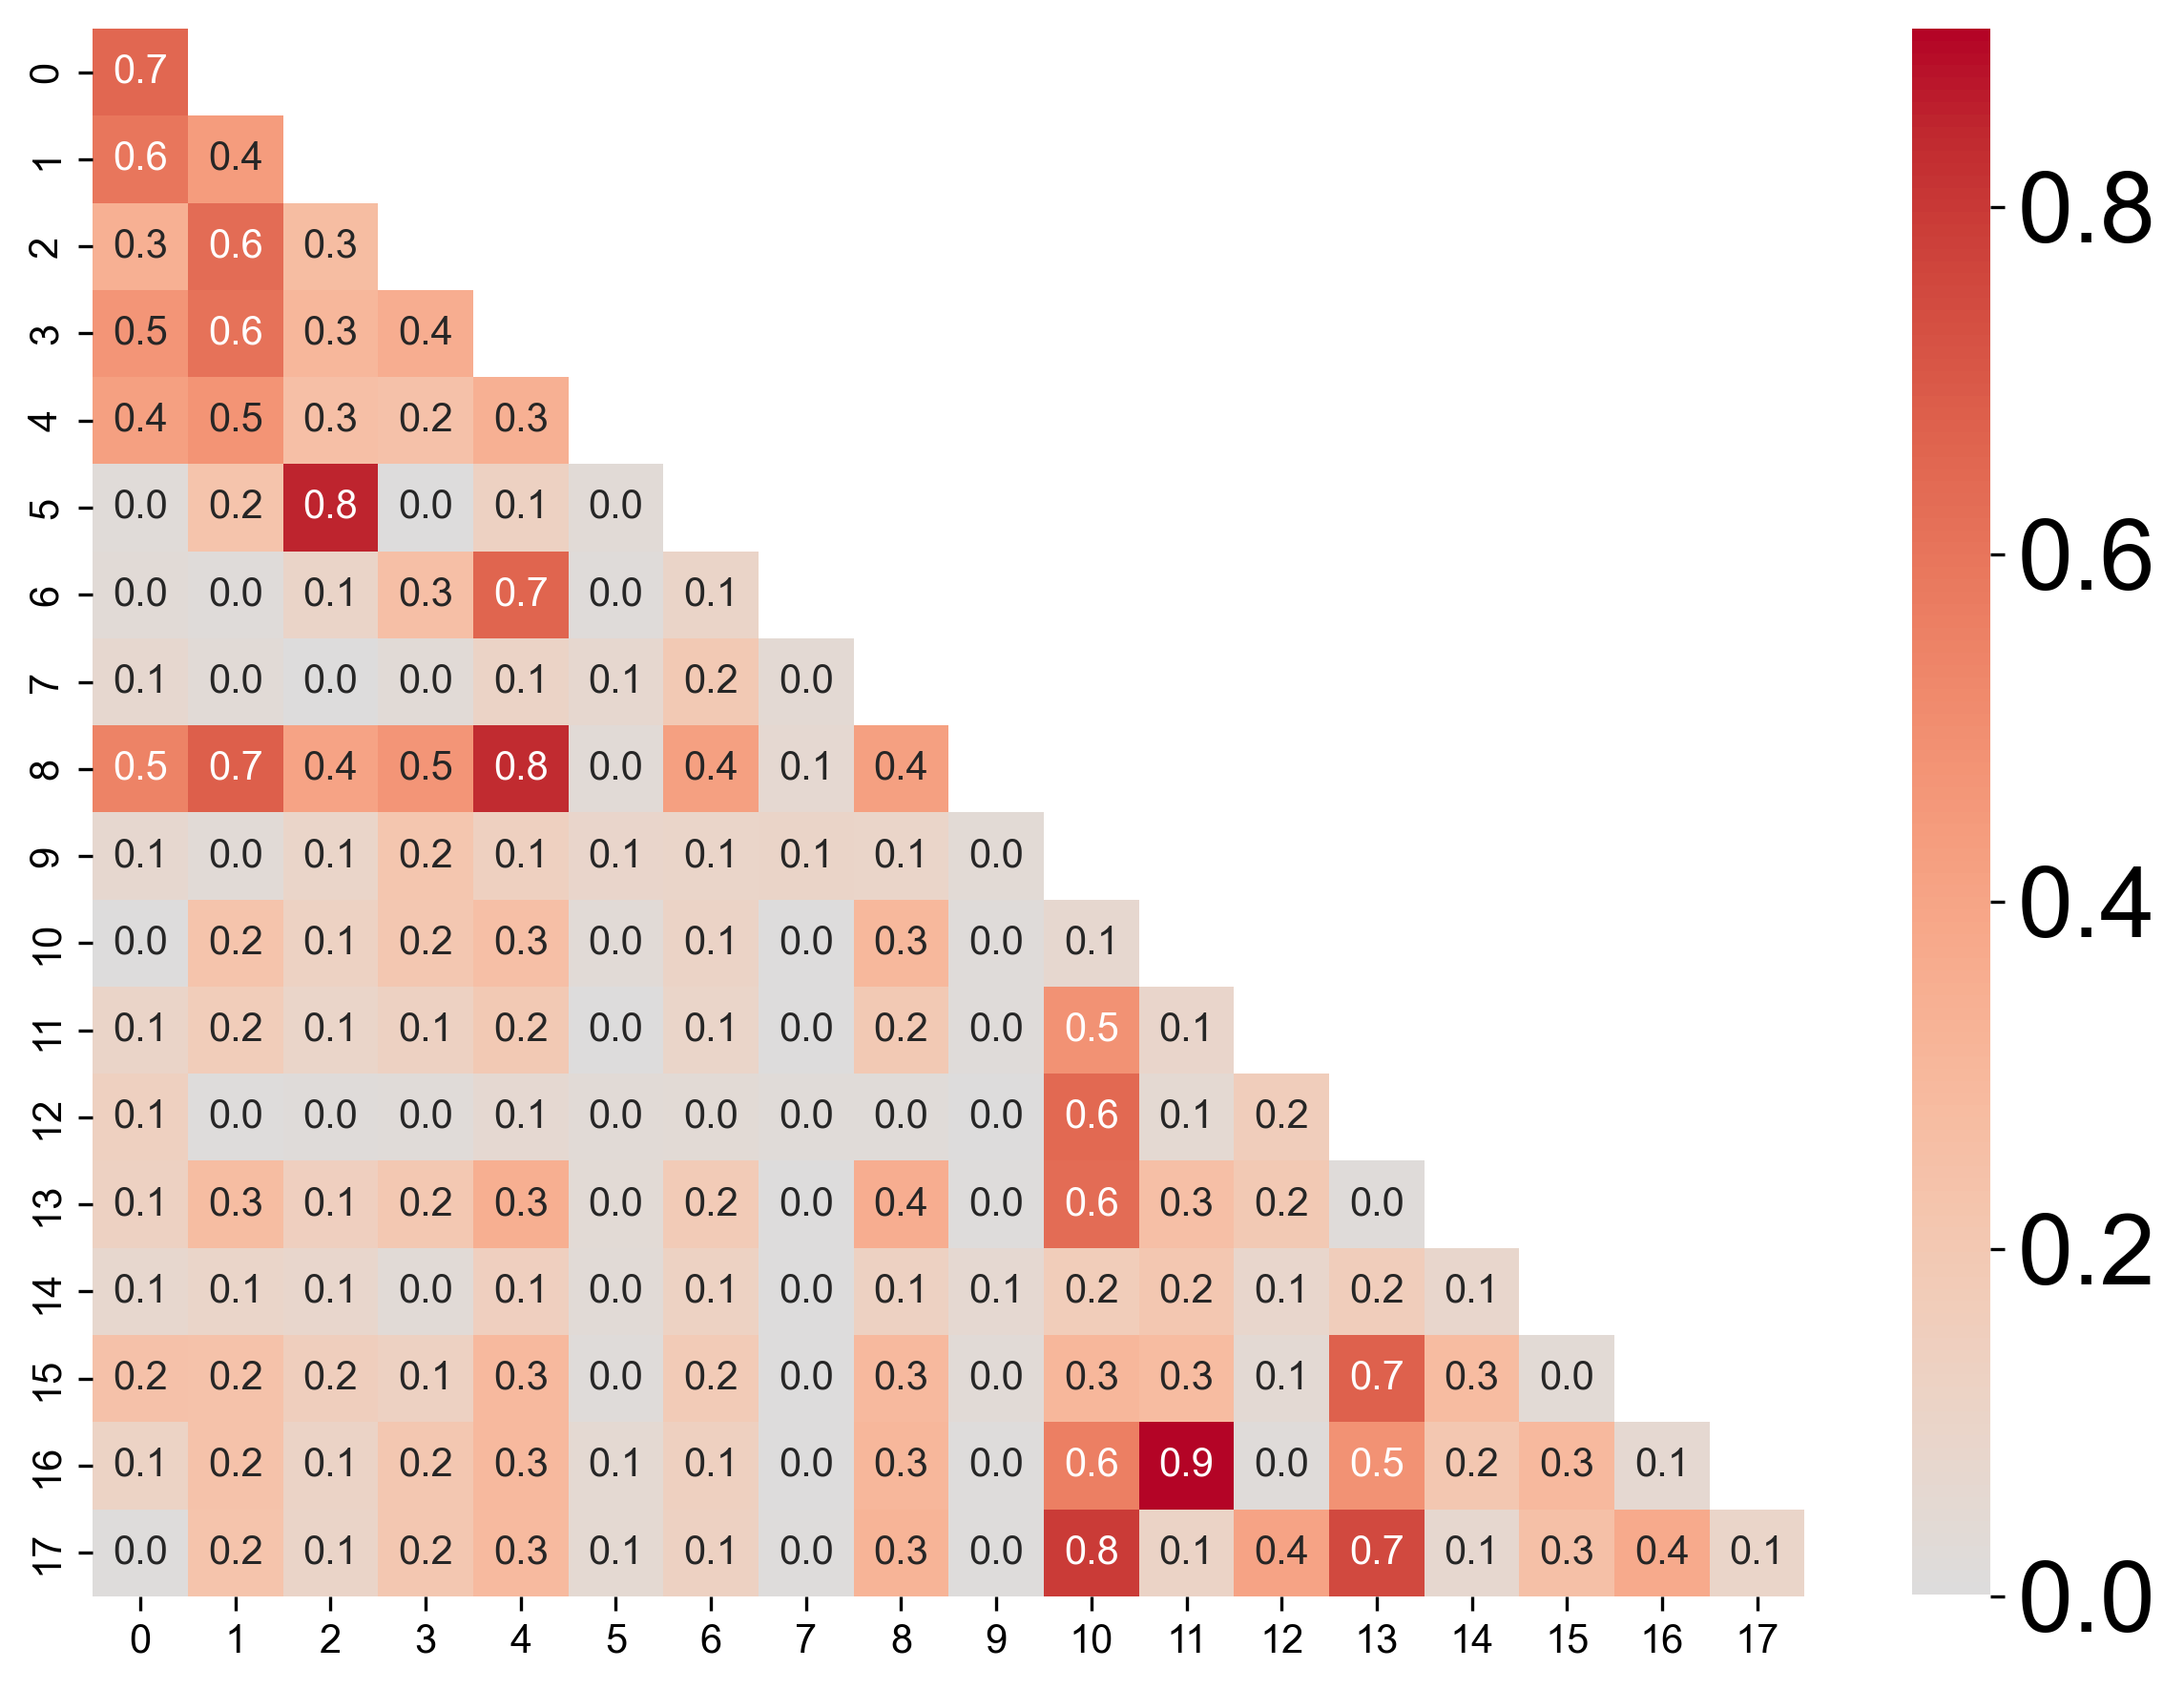

In [10]:
# Figure S21
descriptor_correlation_matrix = draw_correlation_map(
    all_X,
    figure_size=(8, 6),
    colors="coolwarm",
    annot=True,
    show_label=True,
    target=y,
)
plt.savefig(FIGURE_DIR / "FigureS21_descriptor_correlation_map_xtb.png", dpi=300, bbox_inches="tight")
descriptor_correlation_matrix


# 5-Fold Validation [REVIEWER-RUNNABLE]

Runs the reported random five-fold CatBoost validation from released descriptors.


In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
all_r2s = []
all_pred = np.zeros_like(y, dtype=float)

for train_ids, test_ids in kf.split(all_X):
    model = CatBoostRegressor(
        iterations=10000,
        learning_rate=0.01,
        depth=6,
        verbose=0,
        random_state=0,
    )
    model.fit(all_X[train_ids], y[train_ids])
    y_pred = model.predict(all_X[test_ids])

    fold_r2 = r2_score(y[test_ids], y_pred)
    fold_mae = mean_absolute_error(y[test_ids], y_pred)
    fold_mse = mean_squared_error(y[test_ids], y_pred)
    print(f"R2: {fold_r2:.3f}, MAE: {fold_mae:.3f}, MSE: {fold_mse:.3f}")

    all_r2s.append(fold_r2)
    all_pred[test_ids] = y_pred

print(f"Mean of 5-Fold R2: {np.mean(all_r2s):.3f}")


R2: 0.820, MAE: 1.863, MSE: 7.162
R2: 0.816, MAE: 1.948, MSE: 7.513
R2: 0.829, MAE: 1.841, MSE: 6.654
R2: 0.836, MAE: 1.836, MSE: 6.543
R2: 0.848, MAE: 1.810, MSE: 6.328
Mean of 5-Fold R2: 0.830


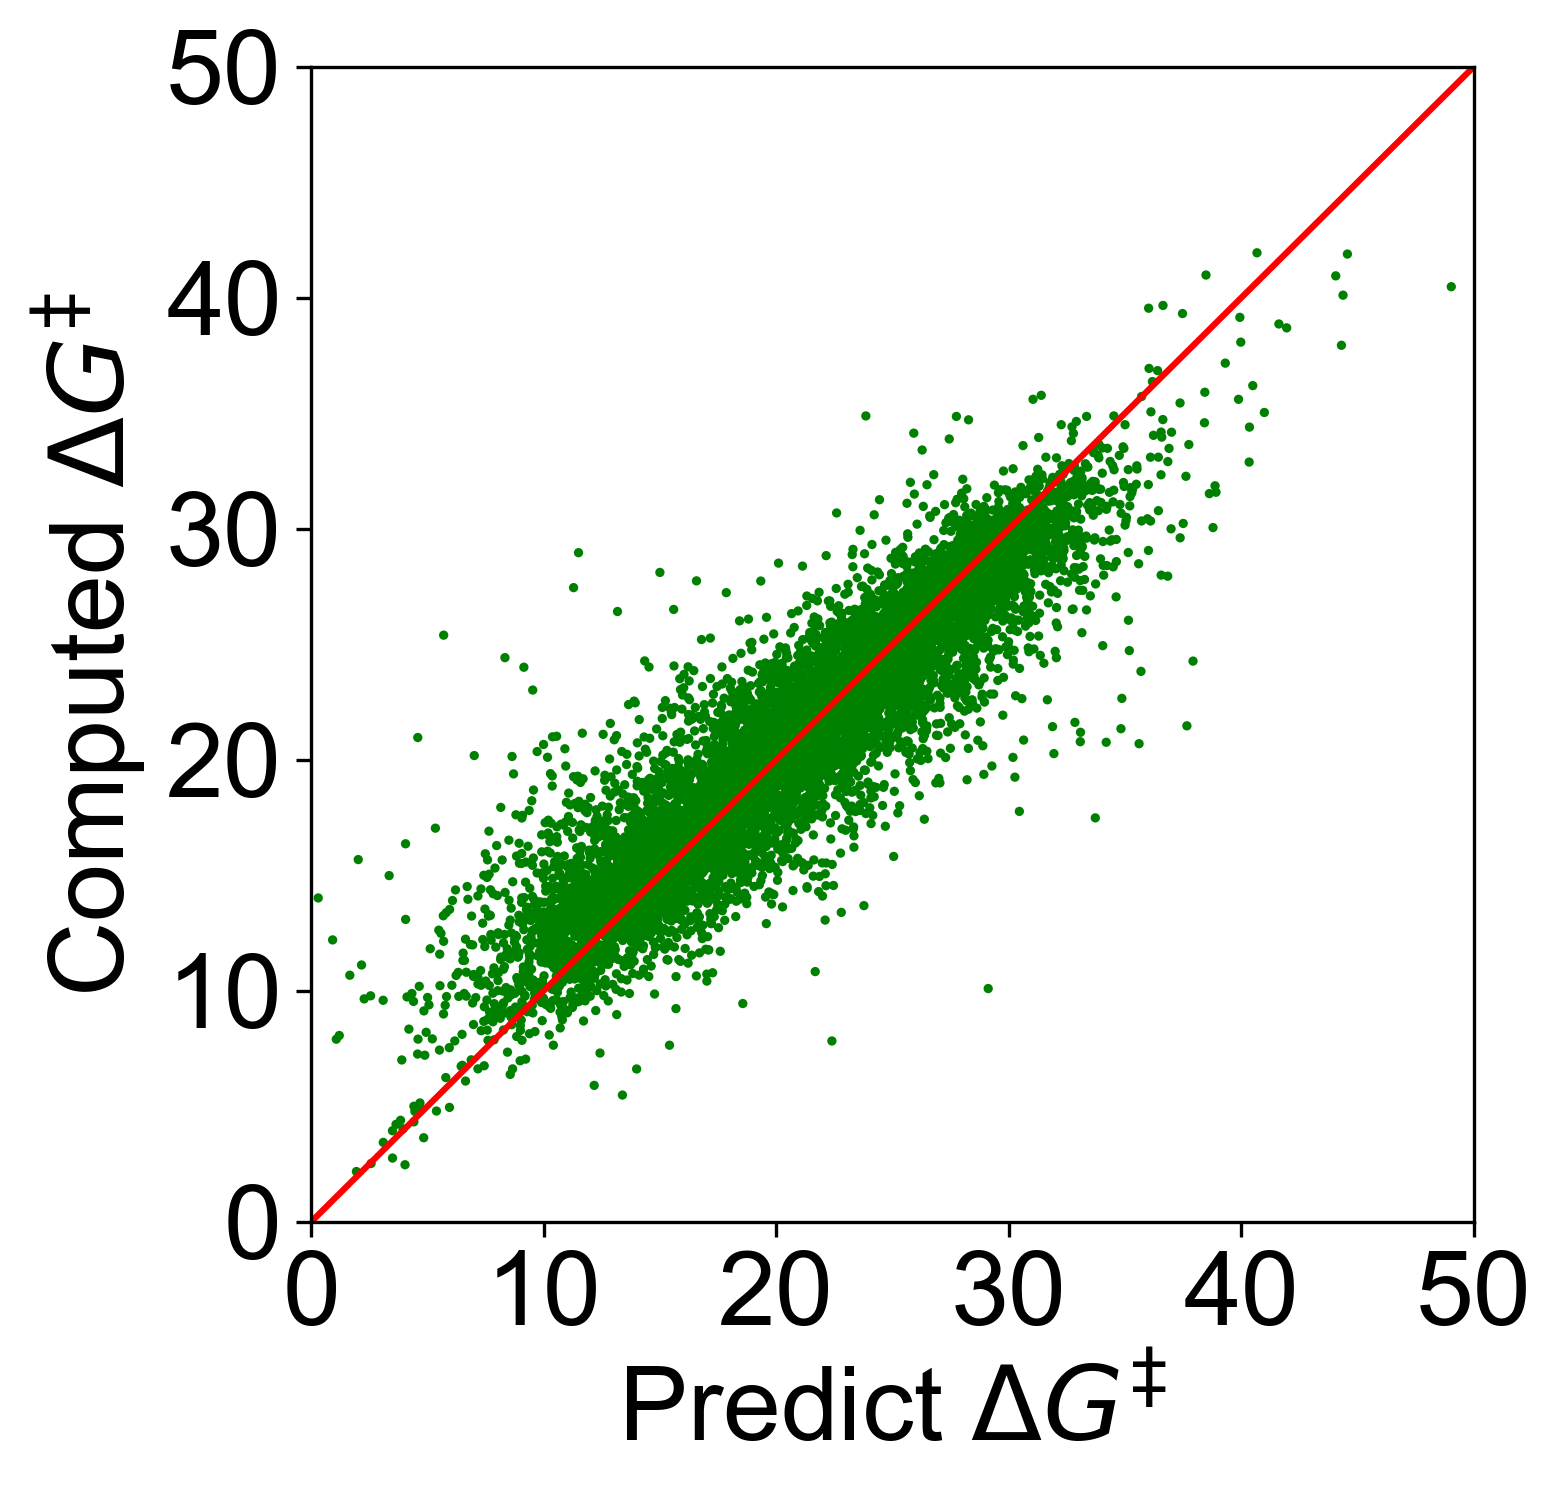

In [12]:
# Figure 6B
plot_scatter_with_metrics(
    y,
    all_pred,
    min_=0,
    max_=50,
    show=False,
)
plt.savefig(FIGURE_DIR / "Figure6B_model_validation_xtb.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.01,
    depth=6,
    verbose=0,
    random_state=0,
)
model.fit(all_X, y)
feature_importances = model.feature_importances_


In [14]:
des_name_std_sorted = [
    '$\\Delta G_{\\mathrm{rxn}}$',                 # deltaG
    'LB-B· $P^{\\mathrm{spin}}$',                  # B_N B_spin
    'LB-B· $q^{\\mathrm{B}}_{\\mathrm{H}}$',       # B_N B_Hirshfield_charge
    'LB-B· $d_{\\mathrm{LB-B}}$',                  # B_N B_N_dist
    'LB-B· $E_{\\mathrm{SOMO}}$',                  # B_N Alpha-HOMO
    'LB-B-Cl $q^{\\mathrm{B}}_{\\mathrm{H}}$',     # B_N_Cl B_Hirshfield_charge
    'LB-B-Cl $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',    # B_N_Cl Cl_Hirshfield_charge
    'LB-B· $d_{\\mathrm{B-Cl}}$',                  # B_N_Cl N_Cl_dist
    'LB-B-Cl $E_{\\mathrm{LUMO}}$',                # B_N_Cl LUMO
    'LB-B-Cl $\\%V_{\\mathrm{bur}}$',              # B_N_Cl Bv6radius
    'Cl-C $q^{\\mathrm{Cl}}_{\\mathrm{H}}$',       # C_Cl Cl_Hirshfield_charge
    'Cl-C $q^{\\mathrm{C}}_{\\mathrm{H}}$',        # C_Cl C_Hirshfield_charge
    'Cl-C $d_{\\mathrm{Cl-C}}$',                   # C_Cl C_Cl_dist
    'Cl-C $E_{\\mathrm{LUMO}}$',                   # C_Cl LUMO
    'C_Cl $\\%V_{\\mathrm{bur}}$',                 # C_Cl Bv6radius
    'C· $P^{\\mathrm{spin}}$',                     # C C_spin
    'C· $q^{\\mathrm{C}}_{\\mathrm{H}}$',          # C C_Hirshfield_charge
    'C· $E_{\\mathrm{SOMO}}$'                      # C Alpha-HOMO
]

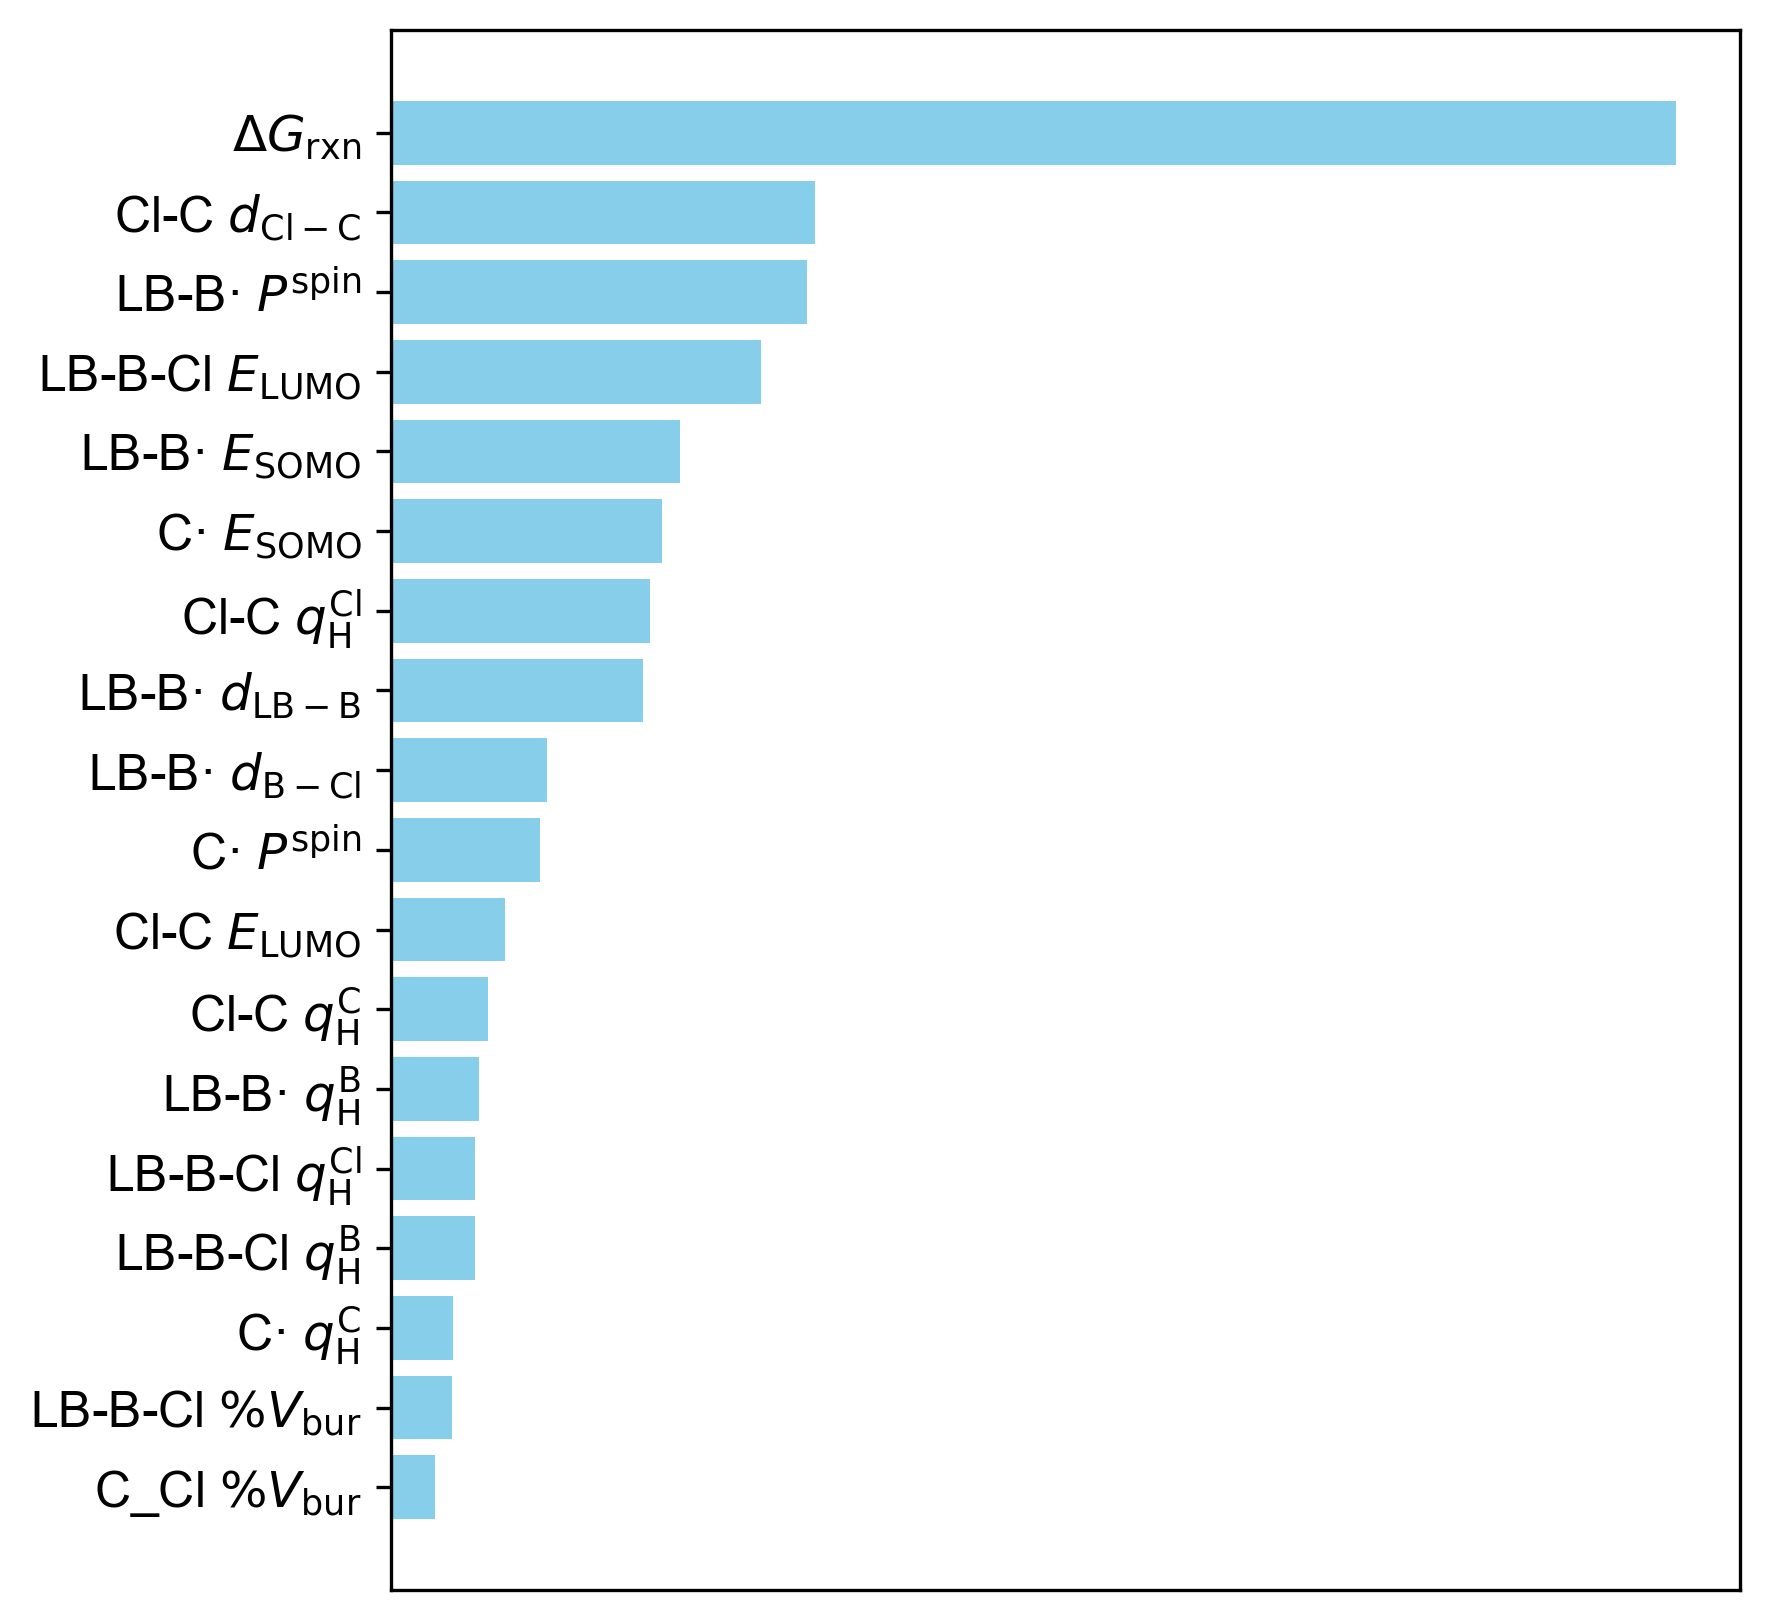

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5.5), dpi=300)
plt.rcParams["font.sans-serif"] = "Arial"
feature_order = np.argsort(feature_importances)
ax.barh(
    np.array(des_name_std_sorted)[feature_order],
    feature_importances[feature_order],
    color="skyblue",
)
ax.set_xticks([])
ax.tick_params(axis="y", labelsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "Figure6C_model_feature_importance_xtb.png", dpi=300, bbox_inches="tight")
plt.show()


# Other Seeds [REVIEWER-RUNNABLE]

Optional robustness check using different random seeds; it is reviewer-runnable but more time-consuming than the main validation.


In [43]:
all_X = np.asarray(all_Xs, dtype=float)
y = data_csv['deltaGa(kcal/mol)'].to_numpy()
kf = KFold(n_splits=5, shuffle=True, random_state=1)

for seed in range(10):
    all_r2s, all_mae, all_mse = [], [], []
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for train_ids, test_ids in list(kf.split(all_X)):
        model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state=0)
        # model = RandomForestRegressor()
        model.fit(all_X[train_ids], y[train_ids])
        y_pred = model.predict(all_X[test_ids])
        all_r2s.append(r2_score(y[test_ids], y_pred))
        all_mae.append(mean_absolute_error(y[test_ids], y_pred))
        all_mse.append(mean_squared_error(y[test_ids], y_pred))
    print(f"Seed: {seed}, R2: {np.mean(all_r2s):.3f}, MAE: {np.mean(all_mae):.3f}, MSE: {np.mean(all_mse):.3f}")

Seed: 0, R2: 0.906, MAE: 1.391, MSE: 3.781
Seed: 1, R2: 0.902, MAE: 1.402, MSE: 3.940
Seed: 2, R2: 0.905, MAE: 1.395, MSE: 3.826
Seed: 3, R2: 0.906, MAE: 1.393, MSE: 3.806
Seed: 4, R2: 0.901, MAE: 1.402, MSE: 3.976
Seed: 5, R2: 0.905, MAE: 1.396, MSE: 3.827
Seed: 6, R2: 0.904, MAE: 1.399, MSE: 3.847
Seed: 7, R2: 0.902, MAE: 1.397, MSE: 3.944
Seed: 8, R2: 0.907, MAE: 1.386, MSE: 3.759
Seed: 9, R2: 0.906, MAE: 1.393, MSE: 3.790


# OOD [REVIEWER-RUNNABLE]

Optional out-of-distribution validation from released descriptors and reaction metadata.


## OOD around Indexes [REVIEWER-RUNNABLE]

Component-index held-out validation; no raw Gaussian folders are required.


OOD by Cl_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7237,2000,0.693829,2.394164,14.513473
1,Cl_Index,2,142,36,7497,1740,0.895497,1.497331,4.003722
2,Cl_Index,3,142,36,7568,1669,0.890117,1.437707,3.785129
3,Cl_Index,4,143,35,7410,1827,0.760429,2.185218,9.025851
4,Cl_Index,5,143,35,7236,2001,0.792468,2.043443,8.362480


Mean fold R2: 0.8064680409470736 MAE: 1.9115726980955805
Overall R2: 0.7969097730616534 MAE: 1.93510236027012


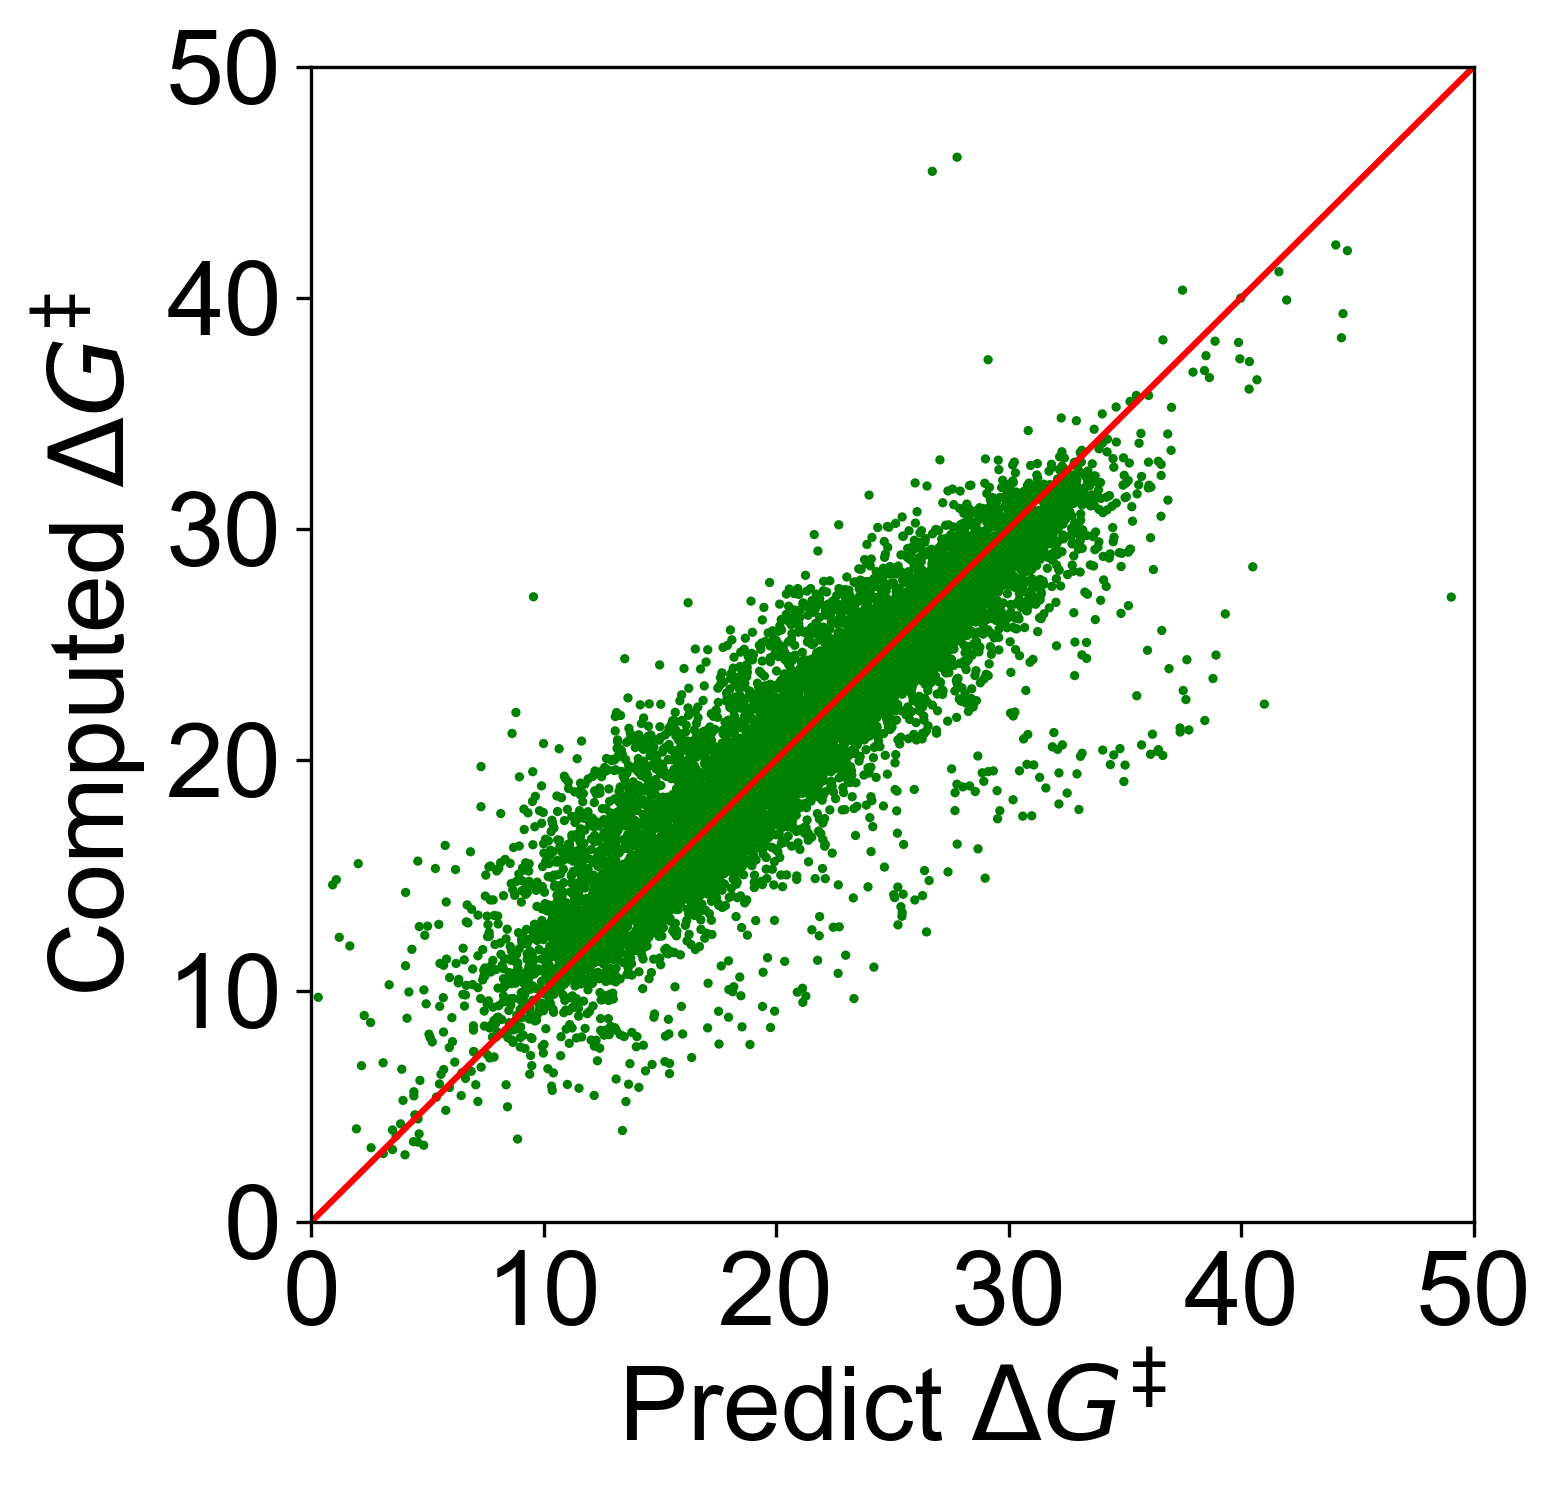

OOD by B_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,B_Index,1,44,11,7868,1369,0.852026,1.919076,6.352181
1,B_Index,2,44,11,7752,1485,0.864832,1.685644,5.344557
2,B_Index,3,44,11,7149,2088,0.861677,1.687065,5.214500
3,B_Index,4,44,11,7422,1815,0.858649,1.657275,5.051280
4,B_Index,5,44,11,6757,2480,0.884466,1.536417,4.822243


Mean fold R2: 0.8643299295654584 MAE: 1.6970954336078656
Overall R2: 0.8691997040718249 MAE: 1.674922200539898


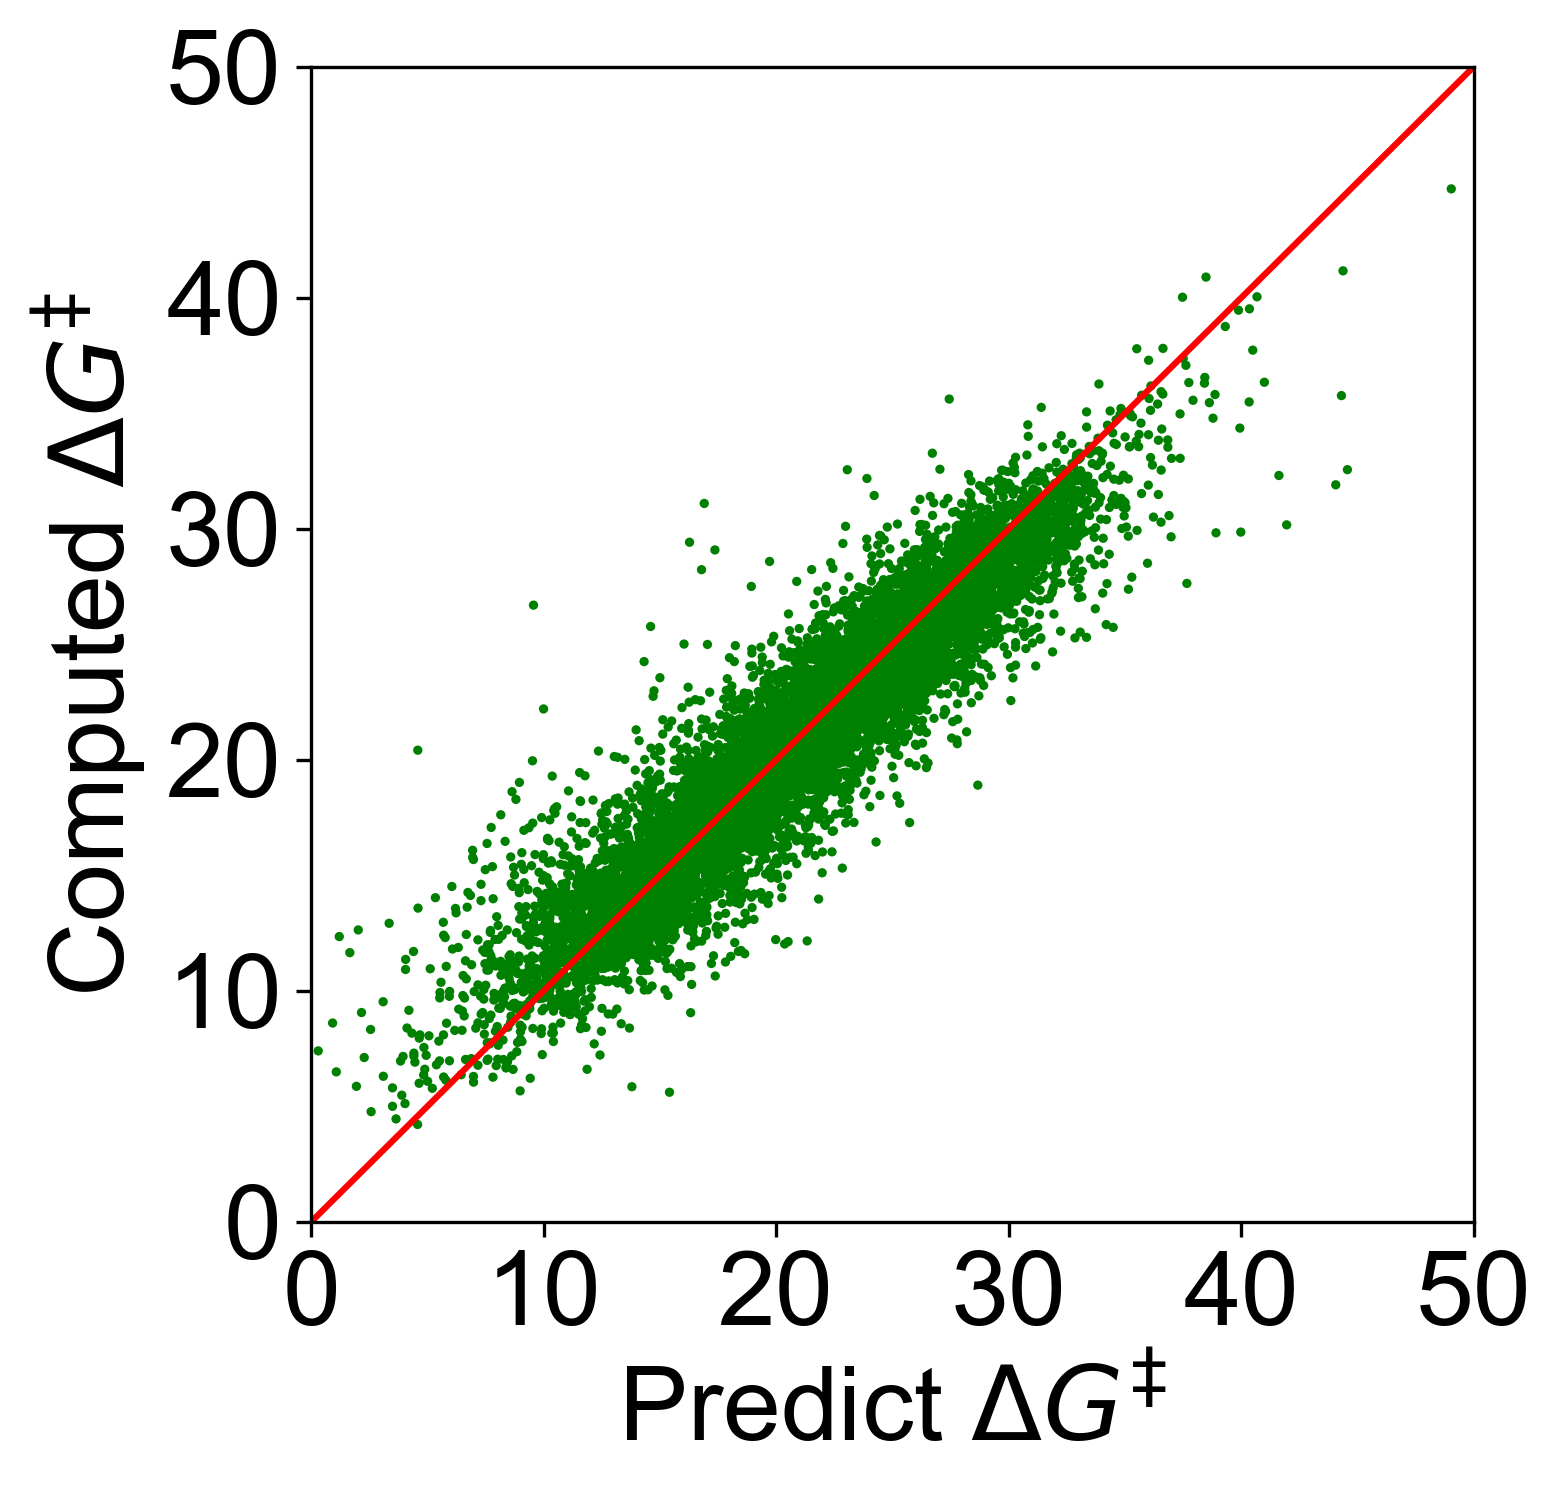

OOD by Nu_Index


,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Nu_Index,1,307,77,6783,2454,0.837162,1.712112,6.479585
1,Nu_Index,2,307,77,7501,1736,0.894447,1.523000,4.229997
2,Nu_Index,3,307,77,7673,1564,0.853561,1.595034,5.773963
3,Nu_Index,4,307,77,7516,1721,0.886258,1.651066,5.114178
4,Nu_Index,5,308,76,7475,1762,0.841606,1.673574,5.677906


Mean fold R2: 0.8626069329008461 MAE: 1.6309572460050852
Overall R2: 0.862658841125141 MAE: 1.638021718748413


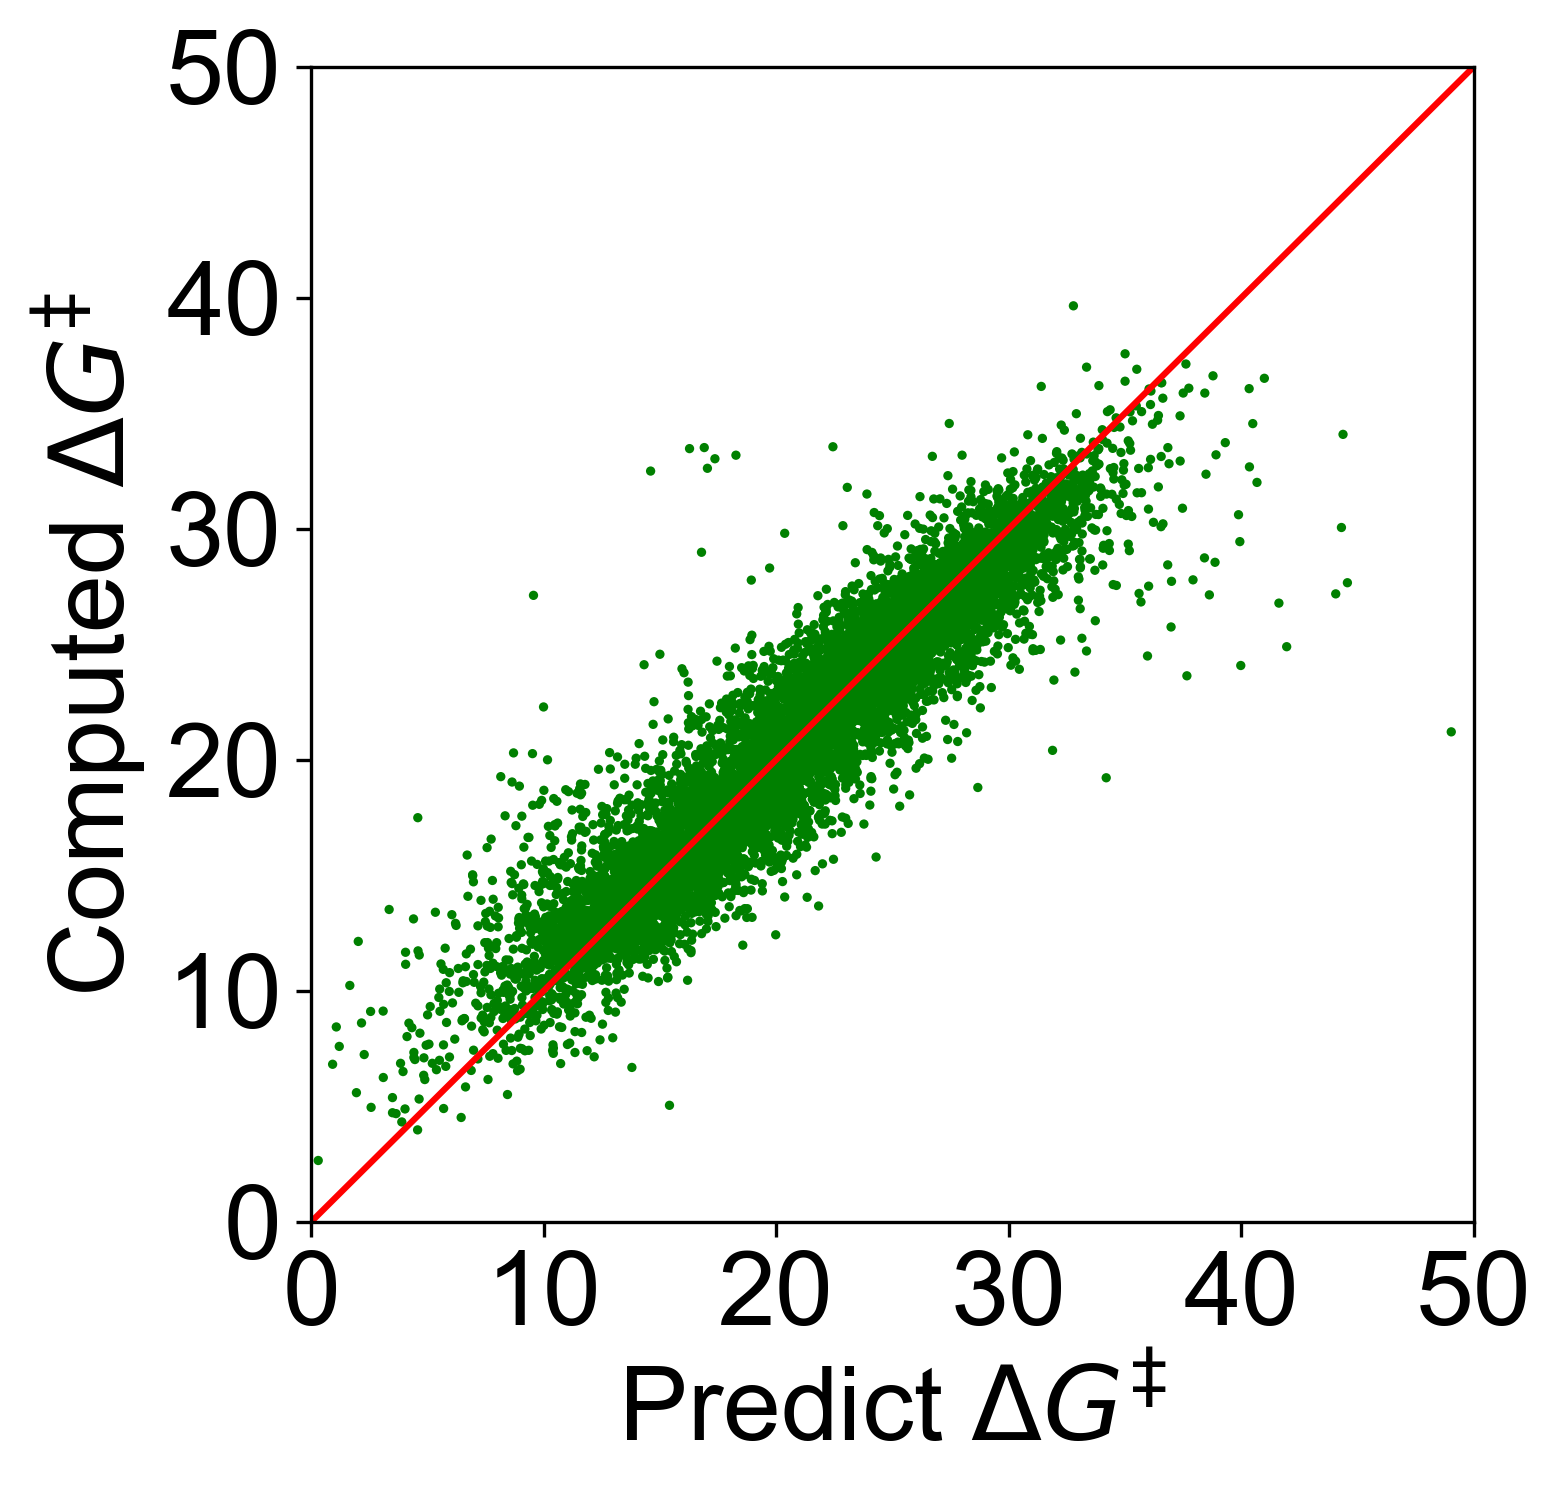

,OOD_axis,fold,train_index_count,test_index_count,train_size,test_size,R2,MAE,MSE
0,Cl_Index,1,142,36,7237,2000,0.693829,2.394164,14.513473
1,Cl_Index,2,142,36,7497,1740,0.895497,1.497331,4.003722
2,Cl_Index,3,142,36,7568,1669,0.890117,1.437707,3.785129
3,Cl_Index,4,143,35,7410,1827,0.760429,2.185218,9.025851
4,Cl_Index,5,143,35,7236,2001,0.792468,2.043443,8.362480
5,B_Index,1,44,11,7868,1369,0.852026,1.919076,6.352181
6,B_Index,2,44,11,7752,1485,0.864832,1.685644,5.344557
7,B_Index,3,44,11,7149,2088,0.861677,1.687065,5.214500
8,B_Index,4,44,11,7422,1815,0.858649,1.657275,5.051280
9,B_Index,5,44,11,6757,2480,0.884466,1.536417,4.822243


In [41]:
def run_index_ood(
    data_df,
    index_column,
    label=None,
    n_splits=5,
    target_column="deltaGa(kcal/mol)",
    min_test_size=2,
):
    label = label or index_column
    index_values = np.sort(data_df[index_column].dropna().unique())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

    result_rows = []
    pred_rows = []
    for fold_id, (train_ids, test_ids) in enumerate(kf.split(index_values), start=1):
        train_values = index_values[train_ids]
        test_values = index_values[test_ids]
        train_df = data_df.loc[data_df[index_column].isin(train_values)].reset_index(drop=True)
        test_df = data_df.loc[data_df[index_column].isin(test_values)].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": label,
            "fold": fold_id,
            "train_index_count": len(train_values),
            "test_index_count": len(test_values),
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": label,
                "fold": fold_id,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


ood_index_configs = {
    "Cl_Index": "Cl_Index",
    "B_Index": "B_Index",
    "N_Index": "Nu_Index",
}
ood_index_results = {}
ood_index_predictions = {}

for index_column, label in ood_index_configs.items():
    result_df, pred_df = run_index_ood(data_csv, index_column=index_column, label=label)
    ood_index_results[label] = result_df
    ood_index_predictions[label] = pred_df

    print(f"OOD by {label}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {label}")
        continue
    print(
        "Mean fold R2:",
        result_df["R2"].mean(),
        "MAE:",
        result_df["MAE"].mean(),
    )
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_index_results = [
    result_df for result_df in ood_index_results.values() if not result_df.empty
]
if nonempty_ood_index_results:
    ood_index_summary = pd.concat(nonempty_ood_index_results, ignore_index=True)
else:
    ood_index_summary = pd.DataFrame()
display(ood_index_summary)


## OOD around Types [REVIEWER-RUNNABLE]

Component-type held-out validation; no raw Gaussian folders are required.


B_type counts:
B_type
R2BH    2500
RBH2    5934
BH3      803

Nu_type counts:
Nu_type
Amine/Aryl N    5897
Phosphine       1833
NHC             1507

Cl_type counts:
Cl_type
CCl4     212
CCl3    1793
CCl2    2107
CCl     5125

OOD by B_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6737,2500,0.808557,2.041933,8.119509
1,B_type,RBH2,3303,5934,0.854490,1.755245,5.614904
2,B_type,BH3,8434,803,0.936600,1.120740,2.367567


Overall R2: 0.850725943433732 MAE: 1.7776780754511132


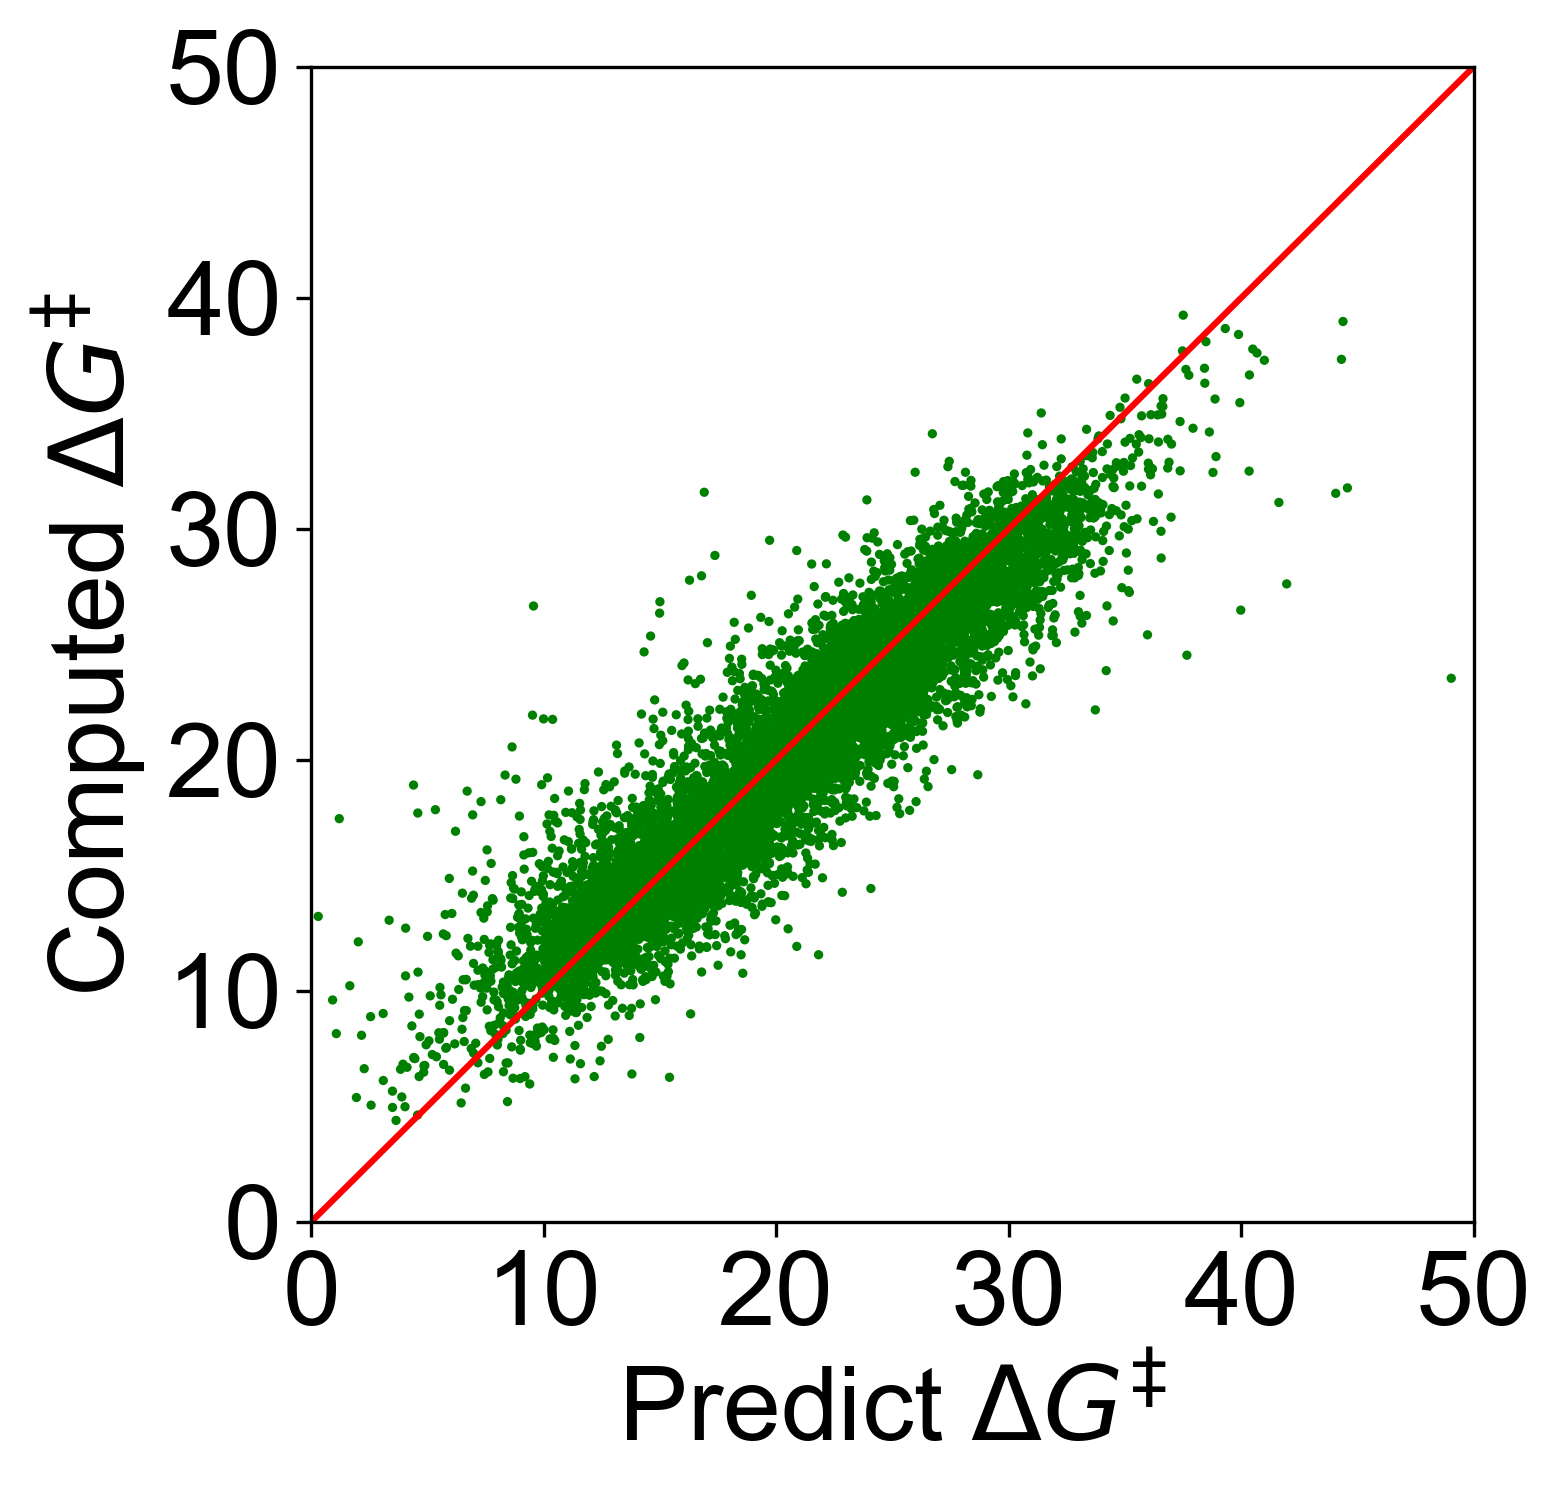

OOD by Nu_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Nu_type,Amine/Aryl N,3340,5897,0.755915,2.410668,10.410664
1,Nu_type,Phosphine,7404,1833,0.503666,2.385533,12.782575
2,Nu_type,NHC,7730,1507,0.750277,2.020231,7.422034


Overall R2: 0.7418642862736917 MAE: 2.3419812718523922


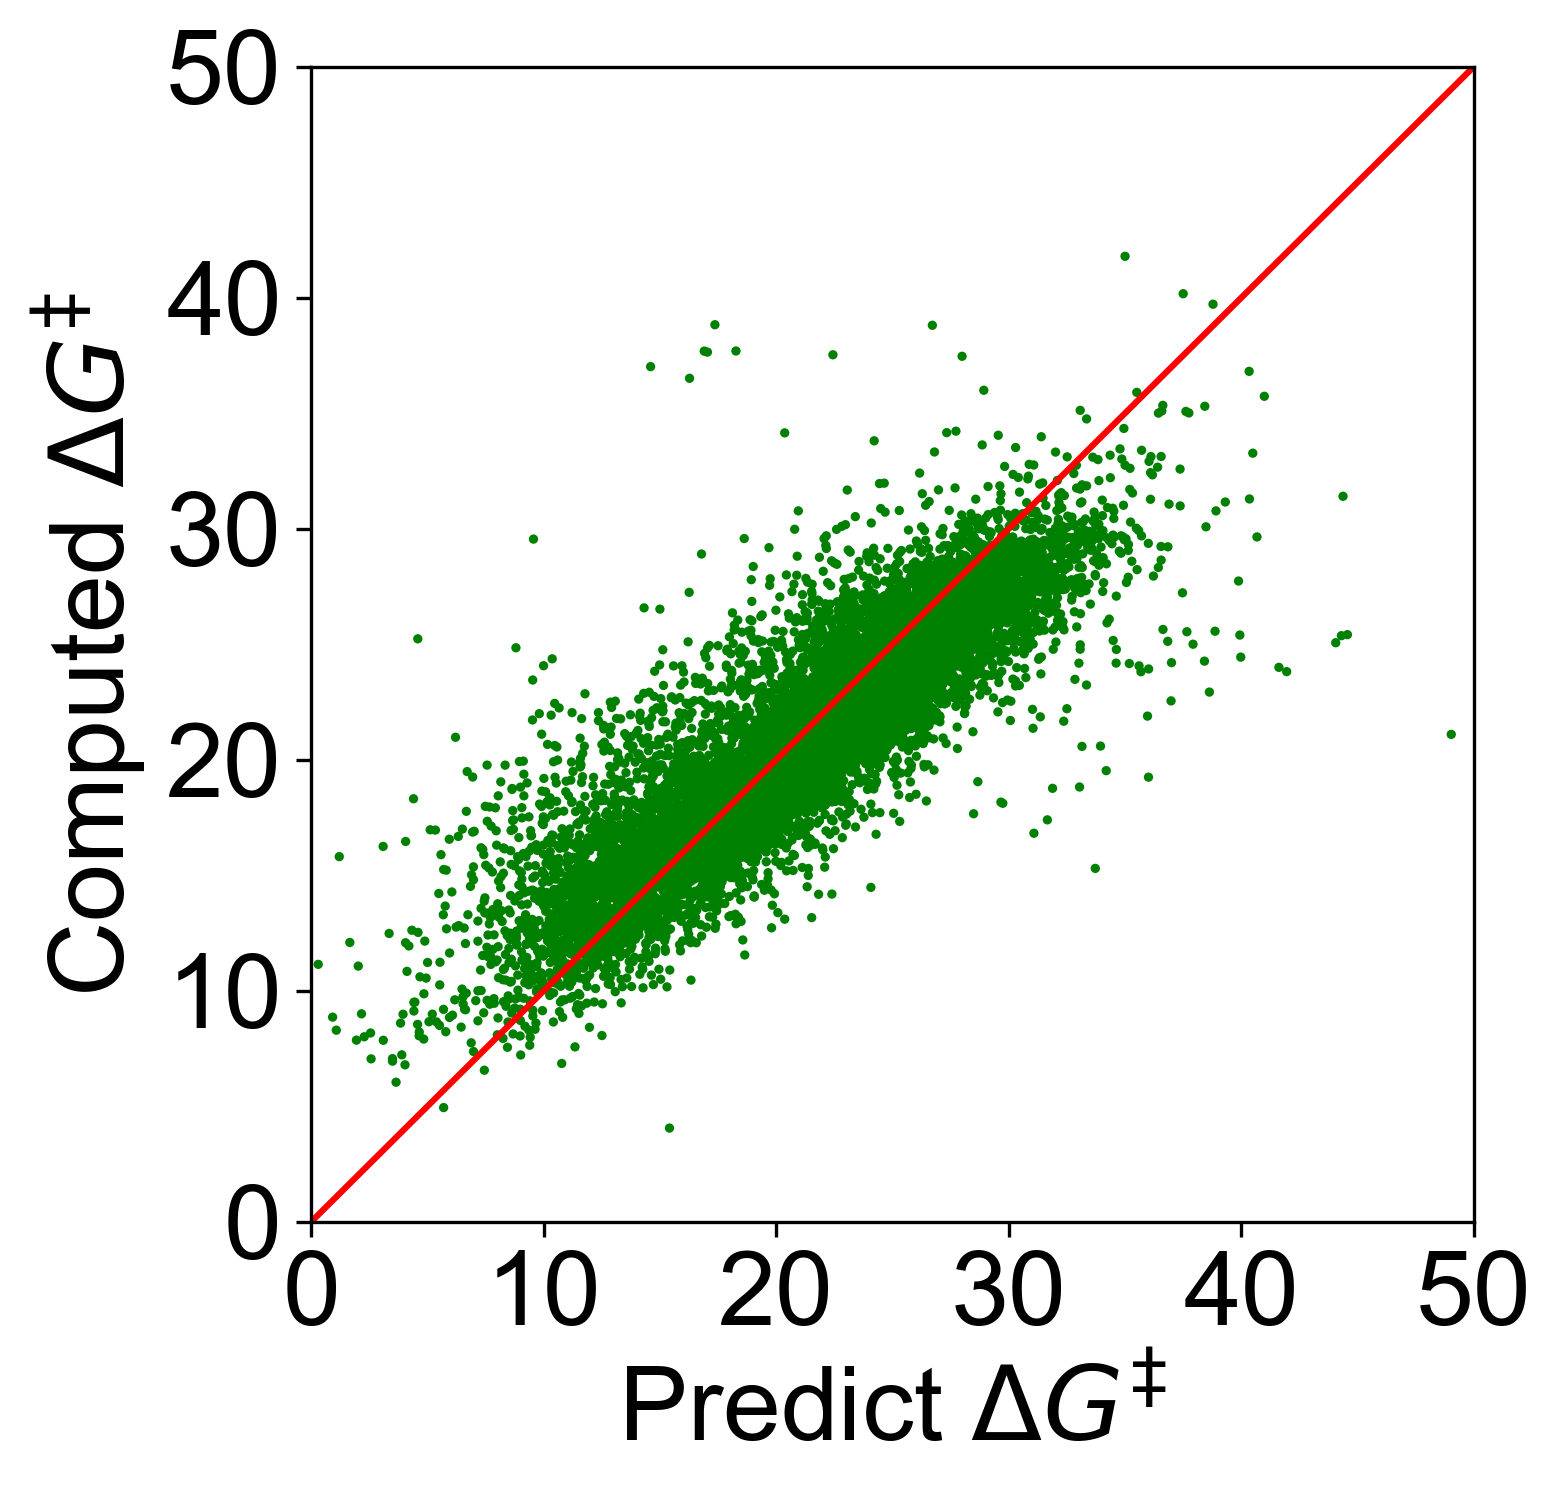

OOD by Cl_type


,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,Cl_type,CCl4,9025,212,0.894737,1.378639,2.843366
1,Cl_type,CCl3,7444,1793,0.903820,1.412401,3.526066
2,Cl_type,CCl2,7130,2107,0.894317,1.485385,4.010414
3,Cl_type,CCl,4112,5125,0.576747,3.267642,18.148714


Overall R2: 0.7085780652441118 MAE: 2.4576242720260657


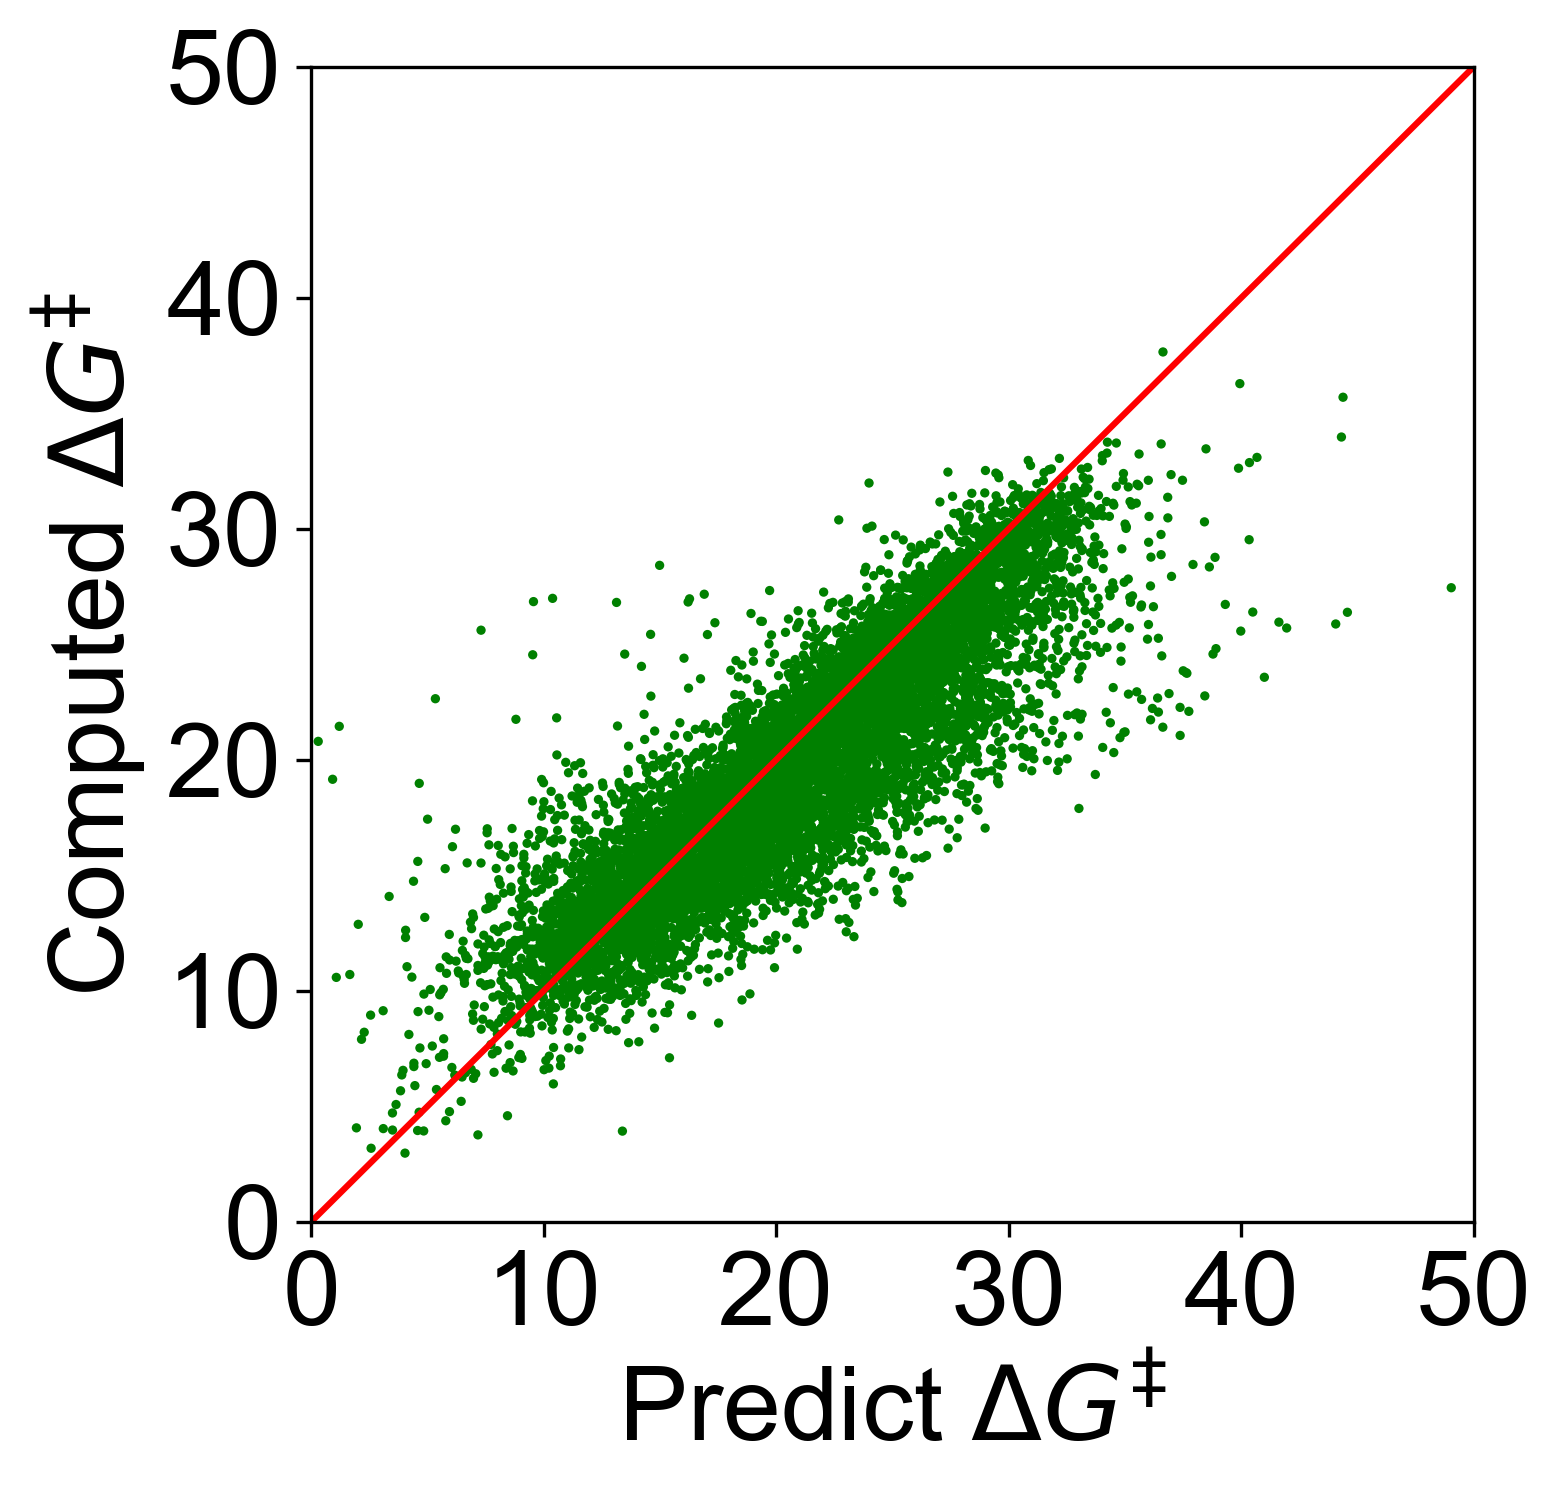

,OOD_axis,heldout_type,train_size,test_size,R2,MAE,MSE
0,B_type,R2BH,6737,2500,0.808557,2.041933,8.119509
1,B_type,RBH2,3303,5934,0.854490,1.755245,5.614904
2,B_type,BH3,8434,803,0.936600,1.120740,2.367567
3,Nu_type,Amine/Aryl N,3340,5897,0.755915,2.410668,10.410664
4,Nu_type,Phosphine,7404,1833,0.503666,2.385533,12.782575
5,Nu_type,NHC,7730,1507,0.750277,2.020231,7.422034
6,Cl_type,CCl4,9025,212,0.894737,1.378639,2.843366
7,Cl_type,CCl3,7444,1793,0.903820,1.412401,3.526066
8,Cl_type,CCl2,7130,2107,0.894317,1.485385,4.010414
9,Cl_type,CCl,4112,5125,0.576747,3.267642,18.148714


In [42]:
def add_ood_type_columns(df):
    typed_df = df.copy()
    typed_df["B_type"] = typed_df["B_smiles"].map(get_boron_type)
    typed_df["Nu_type"] = typed_df["N_Index"].map(get_lb_type)
    typed_df["Cl_type"] = typed_df["Cl_smiles"].map(get_cl_substrate_type)
    return typed_df


def run_type_ood(
    typed_df,
    type_column,
    type_order=None,
    target_column="deltaGa(kcal/mol)",
    min_test_size=2,
):
    if type_order is None:
        type_order = sorted(typed_df[type_column].dropna().unique())

    result_rows = []
    pred_rows = []
    for heldout_type in type_order:
        test_df = typed_df.loc[typed_df[type_column] == heldout_type].reset_index(drop=True)
        train_df = typed_df.loc[typed_df[type_column] != heldout_type].reset_index(drop=True)
        if len(test_df) < min_test_size or len(train_df) == 0:
            continue

        train_X = dataframe_to_descriptors(
            train_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        test_X = dataframe_to_descriptors(
            test_df,
            B_N_des_map,
            Cl_des_map,
            duplicate_cl_ids=duplicate_Cl_id,
            show_progress=False,
        )
        train_y = train_df[target_column]
        test_y = test_df[target_column]

        model = CatBoostRegressor(
            iterations=10000,
            learning_rate=0.01,
            depth=6,
            verbose=0,
            random_state=0,
        )
        model.fit(train_X, train_y)
        y_pred = model.predict(test_X)

        result_rows.append({
            "OOD_axis": type_column,
            "heldout_type": heldout_type,
            "train_size": len(train_df),
            "test_size": len(test_df),
            "R2": r2_score(test_y, y_pred),
            "MAE": mean_absolute_error(test_y, y_pred),
            "MSE": mean_squared_error(test_y, y_pred),
        })
        pred_rows.extend(
            {
                "OOD_axis": type_column,
                "heldout_type": heldout_type,
                "y_true": y_true,
                "y_pred": pred,
            }
            for y_true, pred in zip(test_y.to_numpy(), y_pred)
        )

    return pd.DataFrame(result_rows), pd.DataFrame(pred_rows)


data_csv_typed = add_ood_type_columns(data_csv)
ood_type_counts = {
    "B_type": data_csv_typed["B_type"].value_counts().reindex(B_TYPE_ORDER).dropna().astype(int),
    "Nu_type": data_csv_typed["Nu_type"].value_counts().reindex(LB_TYPE_ORDER).dropna().astype(int),
    "Cl_type": data_csv_typed["Cl_type"].value_counts().reindex(CL_SUBSTRATE_TYPE_ORDER).dropna().astype(int),
}
for axis_name, counts in ood_type_counts.items():
    print(f"{axis_name} counts:")
    print(counts.to_string())
    print()


ood_type_results = {}
ood_type_predictions = {}
ood_type_configs = {
    "B_type": B_TYPE_ORDER,
    "Nu_type": LB_TYPE_ORDER,
    "Cl_type": CL_SUBSTRATE_TYPE_ORDER,
}

for type_column, type_order in ood_type_configs.items():
    result_df, pred_df = run_type_ood(
        data_csv_typed,
        type_column=type_column,
        type_order=type_order,
    )
    ood_type_results[type_column] = result_df
    ood_type_predictions[type_column] = pred_df

    print(f"OOD by {type_column}")
    display(result_df)
    if pred_df.empty:
        print(f"No valid OOD folds for {type_column}")
        continue
    print(
        "Overall R2:",
        r2_score(pred_df["y_true"], pred_df["y_pred"]),
        "MAE:",
        mean_absolute_error(pred_df["y_true"], pred_df["y_pred"]),
    )
    plot_scatter_with_metrics(
        pred_df["y_true"].to_numpy(),
        pred_df["y_pred"].to_numpy(),
        min_=0,
        max_=50,
    )


nonempty_ood_type_results = [
    result_df for result_df in ood_type_results.values() if not result_df.empty
]
if nonempty_ood_type_results:
    ood_type_summary = pd.concat(nonempty_ood_type_results, ignore_index=True)
else:
    ood_type_summary = pd.DataFrame()
display(ood_type_summary)
